### Question 1

### Basic Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
banking_df = pd.read_csv("C:/Gen-AI/Py-training/Banking_churn_prediction.csv")
banking_df.head(10)
print ("Basic Analysis")
print (f"Size of the data - {banking_df.shape}")
print (banking_df.info())
print(banking_df.isna().sum())
print(banking_df.describe())




Basic Analysis
Size of the data - (28382, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  object 
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  object 
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null 

### Univariant Analysis

In [4]:
banking_df.columns

Index(['customer_id', 'vintage', 'age', 'gender', 'dependents', 'occupation',
       'city', 'customer_nw_category', 'branch_code', 'current_balance',
       'previous_month_end_balance', 'average_monthly_balance_prevQ',
       'average_monthly_balance_prevQ2', 'current_month_credit',
       'previous_month_credit', 'current_month_debit', 'previous_month_debit',
       'current_month_balance', 'previous_month_balance', 'churn',
       'last_transaction'],
      dtype='object')

### age : Numerical / quantitative


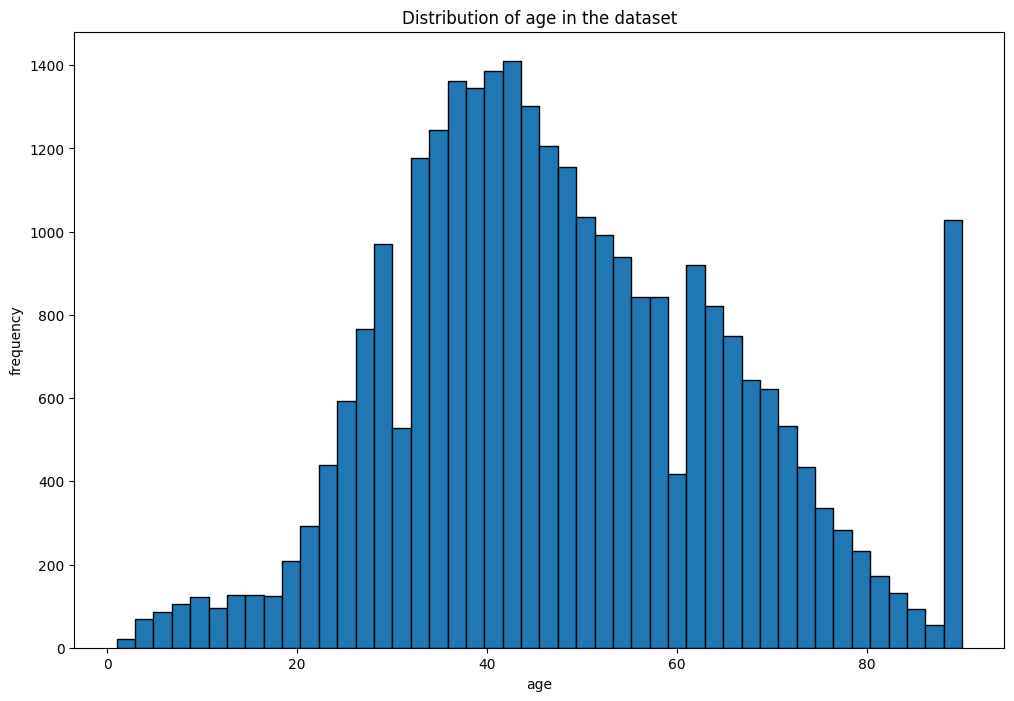

In [15]:
plt.figure(figsize=(12,8))
plt.hist(banking_df['age'], bins=46, edgecolor='k')
plt.title("Distribution of age in the dataset")
plt.xlabel("age")
plt.ylabel("frequency")
plt.show()

### gender : Category

<Axes: xlabel='gender'>

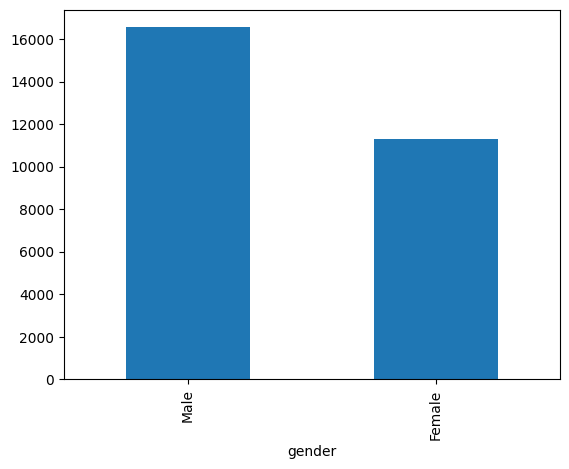

In [16]:
banking_df['gender'].value_counts().plot(kind='bar')




<Axes: xlabel='churn'>

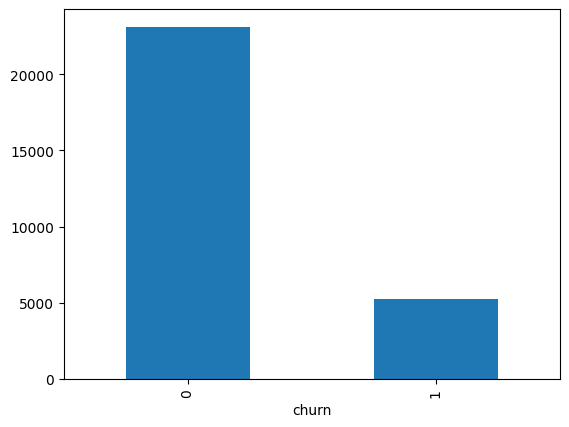

In [6]:
banking_df['churn'].value_counts().plot(kind='bar')

In [17]:
banking_df['branch_code'].value_counts()

branch_code
19      145
6       142
60      128
16      111
8       109
       ... 
3112      1
3558      1
3619      1
2049      1
3030      1
Name: count, Length: 3185, dtype: int64

In [18]:
def skewness_measure(x):
    mean = x.mean()
    std = x.std()
    q1, q2, q3 = x.quantile([0.25, 0.5, 0.75]).values
    mode = x.value_counts().head(1).index.values[0]

    sk1 = (mean - mode)/std
    sk2 = 3*(mean - q2)/std
    skb = (q1+q3 - 2*q2)/(q3-q1)

    print(f"Pearson's first coefficient of skewness = {sk1:.2f},\nPearson's second coefficient of skewness = {sk2:.2f},\nBowley's coefficient of skewness = {skb:.2f}")

In [19]:
skewness_measure(banking_df['age'])

Pearson's first coefficient of skewness = -2.35,
Pearson's second coefficient of skewness = 0.37,
Bowley's coefficient of skewness = 0.17


In [21]:
skewness_measure(banking_df['branch_code'])

Pearson's first coefficient of skewness = 0.97,
Pearson's second coefficient of skewness = 1.13,
Bowley's coefficient of skewness = 0.37


In [22]:
skewness_measure(banking_df['city'])

Pearson's first coefficient of skewness = -0.52,
Pearson's second coefficient of skewness = -0.26,
Bowley's coefficient of skewness = -0.24


In [24]:
skewness_measure(banking_df['current_balance'])

Pearson's first coefficient of skewness = 0.14,
Pearson's second coefficient of skewness = 0.29,
Bowley's coefficient of skewness = 0.38


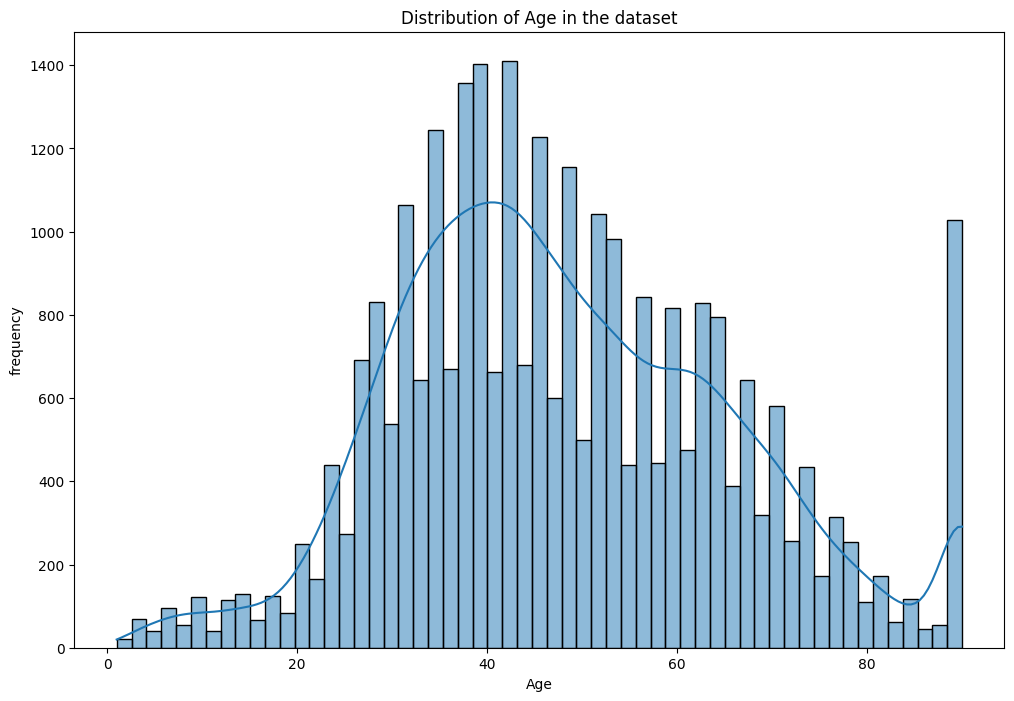

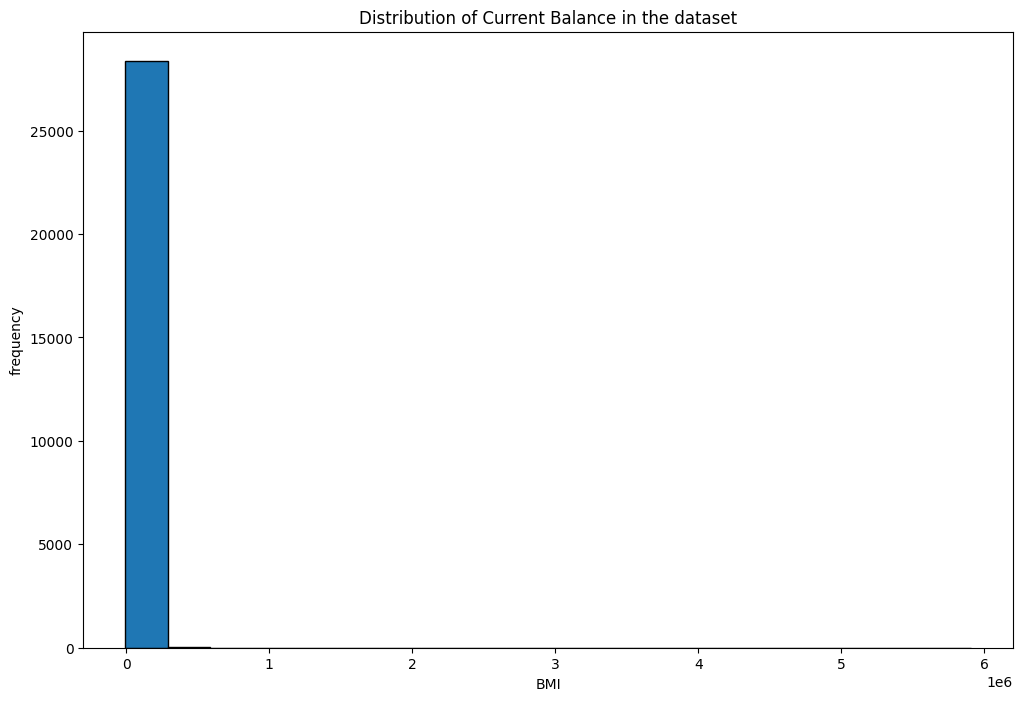

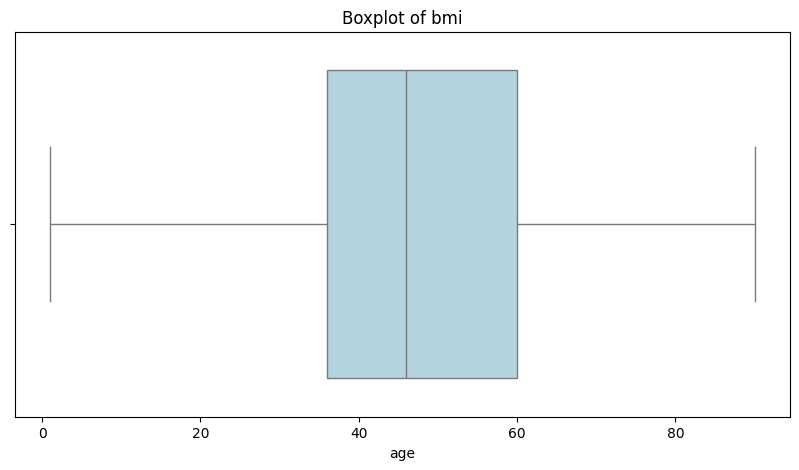

In [ ]:
plt.figure(figsize=(12,8))
sns.histplot(banking_df['age'], kde=True)
plt.title("Distribution of Age in the dataset")
plt.xlabel("Age")
plt.ylabel("frequency")
plt.show()


plt.figure(figsize=(12,8))
plt.hist(banking_df['current_balance'], bins=20, edgecolor='k')
plt.title("Distribution of Current Balance in the dataset")
plt.xlabel("BMI")
plt.ylabel("frequency")
plt.show()

#### box plot

plt.figure(figsize=(10,5))
sns.boxplot(x = banking_df['age'], color='lightblue')
plt.title("Boxplot of Age")
plt.show()

### BiVariant Analysis
### Age vs Dependent

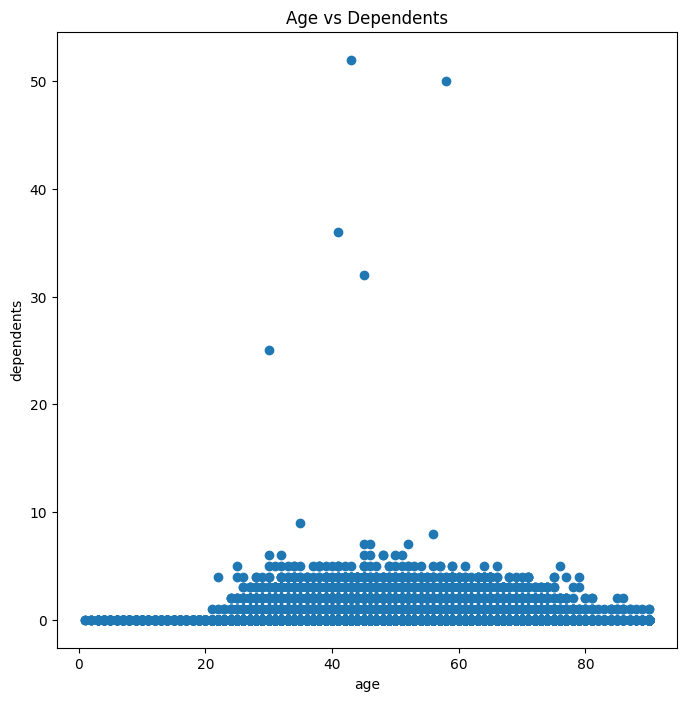

In [33]:
plt.figure(figsize=(8,8))
plt.scatter(banking_df['age'], banking_df['dependents'])
plt.xlabel('age')
plt.ylabel('dependents')
plt.title("Age vs Dependents")
plt.show()



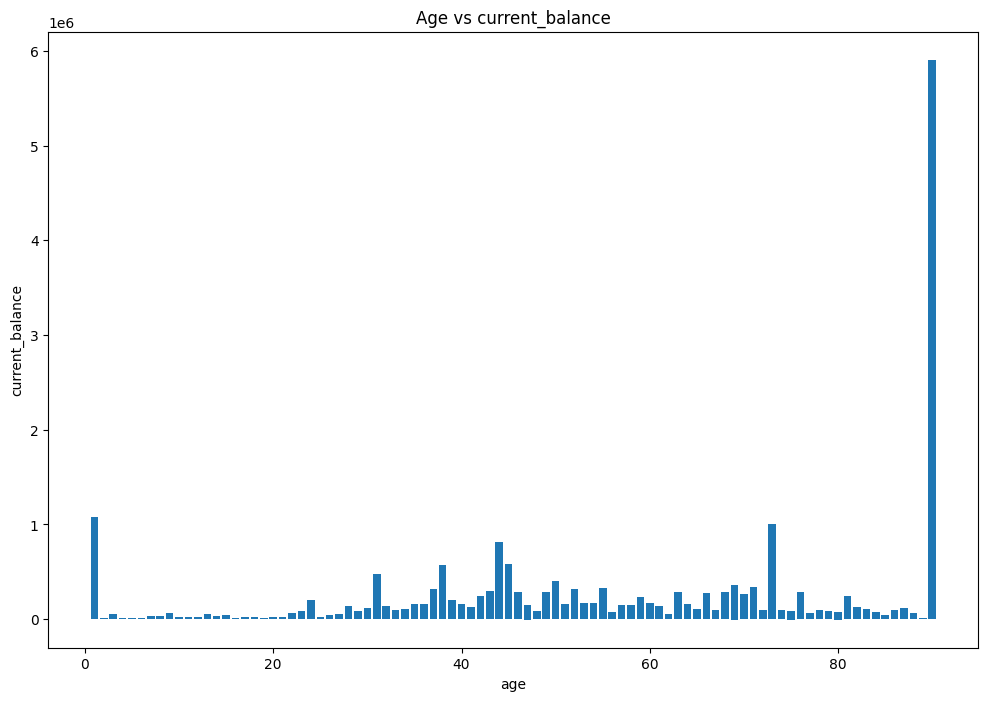

In [3]:
plt.figure(figsize=(12,8))
plt.bar(banking_df['age'], round(banking_df['current_balance'],2))
plt.xlabel('age')
plt.ylabel('current_balance')
plt.title("Age vs current_balance")
plt.show()

<Axes: xlabel='occupation'>

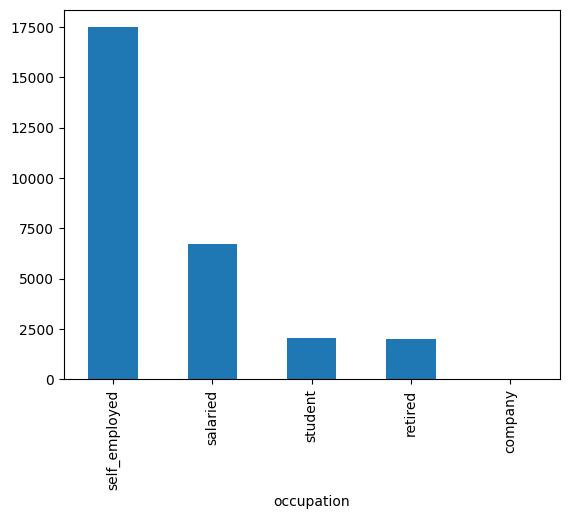

In [5]:
banking_df['occupation'].value_counts().plot(kind='bar')

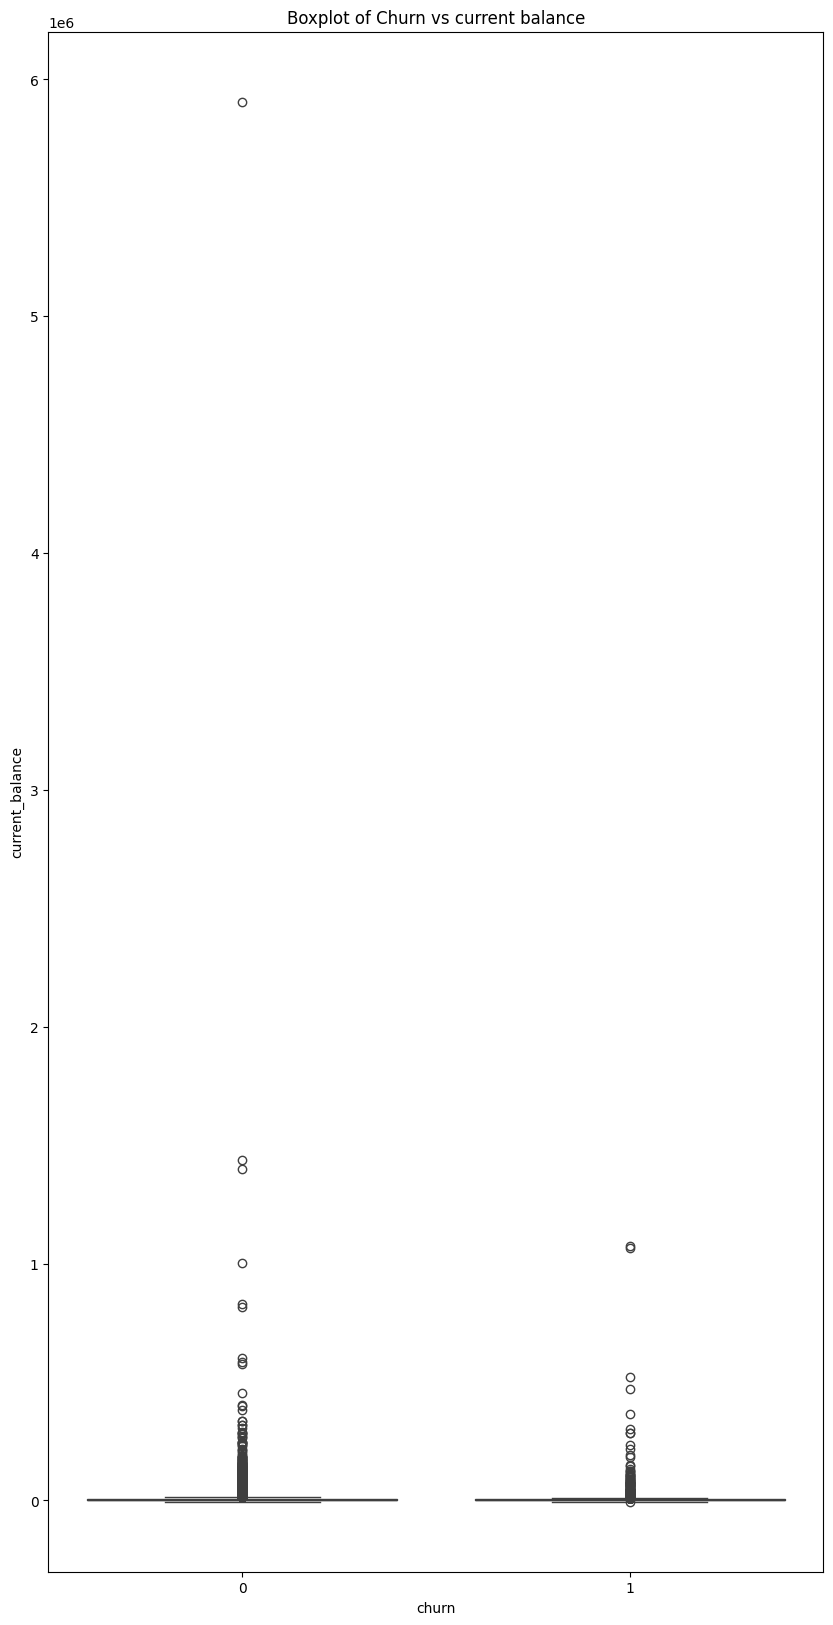

In [19]:
plt.figure(figsize=(10,20))
sns.boxplot(x = banking_df['churn'], y = banking_df['current_balance'])
plt.title("Boxplot of Churn vs current balance")
plt.show()

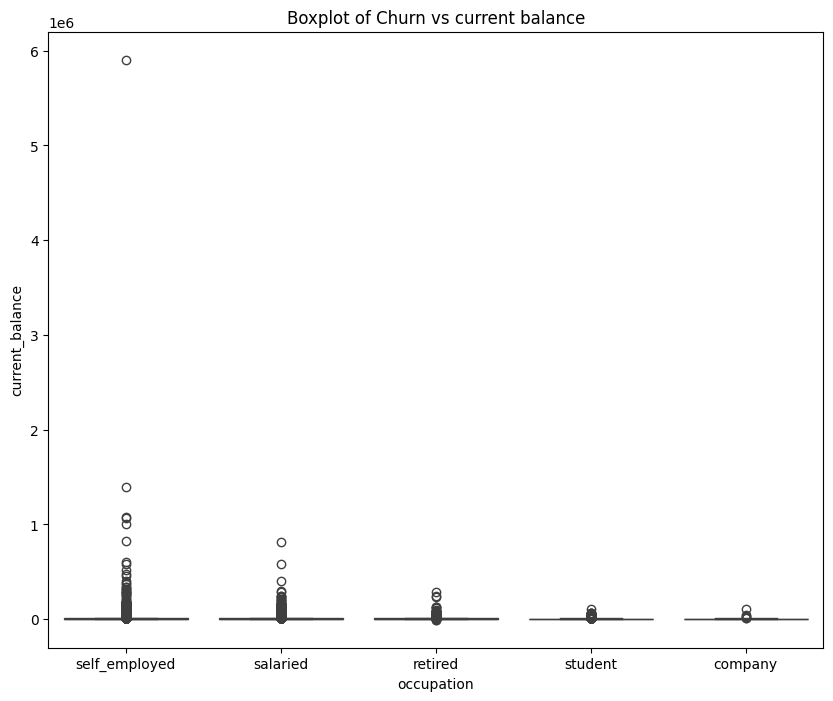

In [23]:
plt.figure(figsize=(10,8))
sns.boxplot(x = banking_df['occupation'], y = banking_df['current_balance'])
plt.title("Boxplot of Churn vs current balance")
plt.show()

In [45]:
print ("H0: Gender has no effect on churn, these are independent")
print ("H1: Gender has an effect on churn habits, these are dependent")
alpha = 0.05

crosstab = pd.crosstab(banking_df['gender'], banking_df['churn'])

crosstab
from scipy.stats import chi2_contingency
chi2_test_result = chi2_contingency(crosstab)
print (f"Statistic {chi2_test_result.statistic}")
print (f"DOF {chi2_test_result.dof}")
print (f"P value {chi2_test_result.pvalue}")
print (f"Exp Frequency {chi2_test_result.expected_freq}")
if chi2_test_result.pvalue < alpha:
    print("Reject the null hypothesis")
else:
    print("fail to reject the null hypothesis")

H0: Gender has no effect on churn, these are independent
H1: Gender has an effect on churn habits, these are dependent
Statistic 11.270738823296812
DOF 1
P value 0.0007873838498074115
Exp Frequency [[ 9216.65028539  2092.34971461]
 [13486.34971461  3061.65028539]]
Reject the null hypothesis


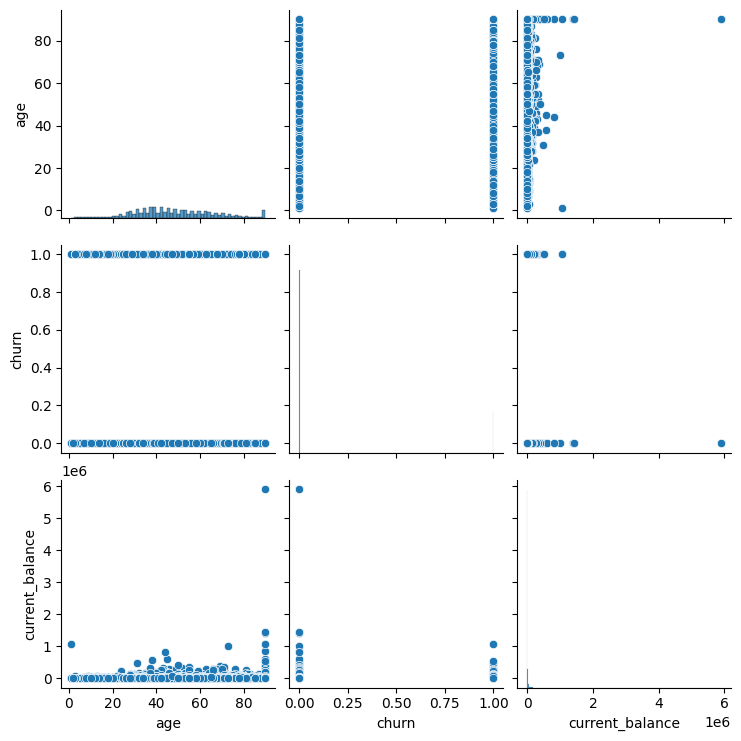

In [48]:
sns.pairplot(banking_df[['age', 'churn', 'current_balance']])  